<a href="https://colab.research.google.com/github/minbj1226/pytorch-basics/blob/main/02_autograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Autograd란 무엇인가?
Autograd는 PyTorch에서 연산 과정을 추적하고, 역전파 시 gradient를 자동으로
계산해주는 자동 미분 엔진

# 2. requires_grad의 의미
requires_grad는 해당 텐서에 대해 gradient를 추적하고 계산할지 여불르 지정하는 속성

# 3. backward()의 역할
backward()는 계산 그래프를 따라 역전파를 수행하여 각 텐서의 gradient를 계산하는 함수

# 4. gradient는 어디에 저장되는가?
gradient 값은 각 텐서의 .grad 속성에 저장

# 5. no_grad()와 detach()의 차이
no_grad()는 수행되는 모든 연산에 대해 gradient 추적을 비활성화한다.
반면 detach()는 특정 텐서를 현재 계산 그래프에서 분리하, 해당 텐서에 대해서는 gradient가 추적되지 않도록 한다.

In [1]:
import torch

x = torch.ones(5)
y = torch.zeros(3)
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w) + b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)

In [2]:
print(f"Gradient function for z = {z.grad_fn}")
print(f"Gradient function for loss = {loss.grad_fn}")

Gradient function for z = <AddBackward0 object at 0x78f0a12d4b20>
Gradient function for loss = <BinaryCrossEntropyWithLogitsBackward0 object at 0x78f0a12d4b20>


In [3]:
loss.backward()
print(w.grad)
print(b.grad)

tensor([[0.2294, 0.0867, 0.3162],
        [0.2294, 0.0867, 0.3162],
        [0.2294, 0.0867, 0.3162],
        [0.2294, 0.0867, 0.3162],
        [0.2294, 0.0867, 0.3162]])
tensor([0.2294, 0.0867, 0.3162])


In [4]:
z = torch.matmul(x, w)+b
print(z.requires_grad)

with torch.no_grad():
  z = torch.matmul(x, w)+b
print(z.requires_grad)

True
False


In [5]:
z = torch.matmul(x, w)+b
z_det = z.detach()
print(z_det.requires_grad)

False


In [6]:
import torch

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math

In [7]:
a = torch.linspace(0.0, 2.0 * math.pi, steps=25, requires_grad=True)
print(a)

tensor([0.0000, 0.2618, 0.5236, 0.7854, 1.0472, 1.3090, 1.5708, 1.8326, 2.0944,
        2.3562, 2.6180, 2.8798, 3.1416, 3.4034, 3.6652, 3.9270, 4.1888, 4.4506,
        4.7124, 4.9742, 5.2360, 5.4978, 5.7596, 6.0214, 6.2832],
       requires_grad=True)


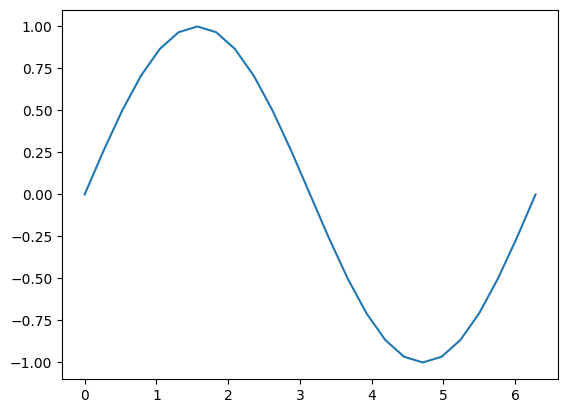

In [8]:
b = torch.sin(a)
plt.plot(a.detach(), b.detach())

In [9]:
print(b)

tensor([ 0.0000e+00,  2.5882e-01,  5.0000e-01,  7.0711e-01,  8.6603e-01,
         9.6593e-01,  1.0000e+00,  9.6593e-01,  8.6603e-01,  7.0711e-01,
         5.0000e-01,  2.5882e-01, -8.7423e-08, -2.5882e-01, -5.0000e-01,
        -7.0711e-01, -8.6603e-01, -9.6593e-01, -1.0000e+00, -9.6593e-01,
        -8.6603e-01, -7.0711e-01, -5.0000e-01, -2.5882e-01,  1.7485e-07],
       grad_fn=<SinBackward0>)


In [10]:
c = 2 * b
print(c)

d = c + 1
print(d)

tensor([ 0.0000e+00,  5.1764e-01,  1.0000e+00,  1.4142e+00,  1.7321e+00,
         1.9319e+00,  2.0000e+00,  1.9319e+00,  1.7321e+00,  1.4142e+00,
         1.0000e+00,  5.1764e-01, -1.7485e-07, -5.1764e-01, -1.0000e+00,
        -1.4142e+00, -1.7321e+00, -1.9319e+00, -2.0000e+00, -1.9319e+00,
        -1.7321e+00, -1.4142e+00, -1.0000e+00, -5.1764e-01,  3.4969e-07],
       grad_fn=<MulBackward0>)
tensor([ 1.0000e+00,  1.5176e+00,  2.0000e+00,  2.4142e+00,  2.7321e+00,
         2.9319e+00,  3.0000e+00,  2.9319e+00,  2.7321e+00,  2.4142e+00,
         2.0000e+00,  1.5176e+00,  1.0000e+00,  4.8236e-01, -3.5763e-07,
        -4.1421e-01, -7.3205e-01, -9.3185e-01, -1.0000e+00, -9.3185e-01,
        -7.3205e-01, -4.1421e-01,  4.7684e-07,  4.8236e-01,  1.0000e+00],
       grad_fn=<AddBackward0>)


In [11]:
out = d.sum()
print(out)

tensor(25., grad_fn=<SumBackward0>)


In [12]:
print("d:")
print(d.grad_fn)
print(d.grad_fn.next_functions)
print(d.grad_fn.next_functions[0][0].next_functions)
print(d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions)
print(
    d.grad_fn.next_functions[0][0]
    .next_functions[0][0]
    .next_functions[0][0]
    .next_functions
)
print("\nc:")
print(c.grad_fn)
print("\nb:")
print(b.grad_fn)
print("\na:")
print(a.grad_fn)

d:
((<MulBackward0 object at 0x78f0a09910c0>, 0), (None, 0))
((<SinBackward0 object at 0x78f0a09910c0>, 0), (None, 0))
((<AccumulateGrad object at 0x78f0a09759f0>, 0),)
()

c:

b:

a:
None


tensor([ 2.0000e+00,  1.9319e+00,  1.7321e+00,  1.4142e+00,  1.0000e+00,
         5.1764e-01, -8.7423e-08, -5.1764e-01, -1.0000e+00, -1.4142e+00,
        -1.7321e+00, -1.9319e+00, -2.0000e+00, -1.9319e+00, -1.7321e+00,
        -1.4142e+00, -1.0000e+00, -5.1764e-01,  2.3850e-08,  5.1764e-01,
         1.0000e+00,  1.4142e+00,  1.7321e+00,  1.9319e+00,  2.0000e+00])


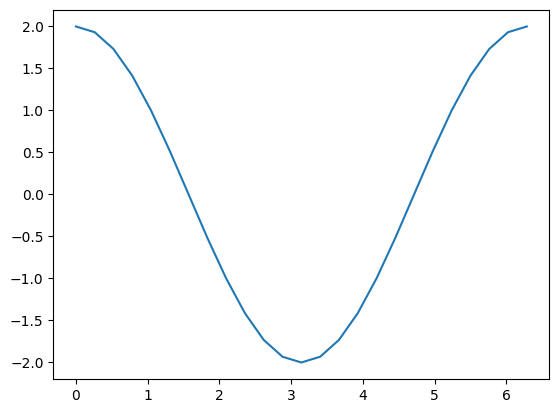

In [13]:
out.backward()
print(a.grad)
plt.plot(a.detach(), a.grad.detach())

In [14]:
BATCH_SIZE = 16
DIM_IN = 1000
HIDDEN_SIZE = 100
DIM_OUT = 10

class TinyModel(torch.nn.Module):
  def __init__(self):
    super(TinyModel, self).__init__()

    self.layer1 = torch.nn.Linear(DIM_IN, HIDDEN_SIZE)
    self.relu = torch.nn.ReLU()
    self.layer2 = torch.nn.Linear(HIDDEN_SIZE, DIM_OUT)

  def forward(self, x):
    x = self.layer1(x)
    x = self.relu(x)
    x = self.layer2(x)
    return x

some_input = torch.randn(BATCH_SIZE, DIM_IN, requires_grad=False)
ideal_output = torch.randn(BATCH_SIZE, DIM_OUT, requires_grad=False)

model = TinyModel()

In [15]:
print(model.layer2.weight[0][0:10])
print(model.layer2.weight.grad)

tensor([-0.0431,  0.0671, -0.0750,  0.0315, -0.0273,  0.0689,  0.0575, -0.0306,
         0.0610,  0.0237], grad_fn=<SliceBackward0>)
None


In [16]:
import torch

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

prediction = model(some_input)
prediction

loss = (ideal_output - prediction).pow(2).sum()
print(loss)

tensor(122.5457, grad_fn=<SumBackward0>)


In [17]:
loss.backward()
print(model.layer2.weight[0][0:10])
print(model.layer2.weight.grad[0][0:10])

tensor([-0.0431,  0.0671, -0.0750,  0.0315, -0.0273,  0.0689,  0.0575, -0.0306,
         0.0610,  0.0237], grad_fn=<SliceBackward0>)
tensor([ 2.9224, -0.6934, -4.0101, -0.9763, -1.8281,  0.1373, -2.3873, -1.0622,
         1.7408, -5.4427])


In [18]:
optimizer.step()
print(model.layer2.weight[0][0:10])
print(model.layer2.weight.grad[0][0:10])

tensor([-0.0460,  0.0678, -0.0710,  0.0324, -0.0255,  0.0688,  0.0599, -0.0295,
         0.0593,  0.0291], grad_fn=<SliceBackward0>)
tensor([ 2.9224, -0.6934, -4.0101, -0.9763, -1.8281,  0.1373, -2.3873, -1.0622,
         1.7408, -5.4427])


In [21]:
print(model.layer2.weight.grad[0][0:10])

for i in range(0, 5):
  prediction = model(some_input) # Corrected typo and assigned to 'prediction'
  loss = (ideal_output - prediction).pow(2).sum() # Use the newly computed 'prediction'
  loss.backward()

print(model.layer2.weight.grad[0][0:10])

optimizer.zero_grad(set_to_none=True)

print(model.layer2.weight.grad[0][0:10])

TypeError: 'NoneType' object is not subscriptable

In [22]:
a = torch.ones(2, 3, requires_grad=True)
print(a)

b1 = 2 * a
print(b1)

a.requires_grad = False
b2 = 2 * a
print(b2)

tensor([[1., 1., 1.],
        [1., 1., 1.]], requires_grad=True)
tensor([[2., 2., 2.],
        [2., 2., 2.]], grad_fn=<MulBackward0>)
tensor([[2., 2., 2.],
        [2., 2., 2.]])


In [23]:
a = torch.ones(2, 3, requires_grad=True) * 2
b = torch.ones(2, 3, requires_grad=True) * 3

c1 = a + b
print(c1)

with torch.no_grad():
    c2 = a + b

print(c2)

c3 = a * b
print(c3)

tensor([[5., 5., 5.],
        [5., 5., 5.]], grad_fn=<AddBackward0>)
tensor([[5., 5., 5.],
        [5., 5., 5.]])
tensor([[6., 6., 6.],
        [6., 6., 6.]], grad_fn=<MulBackward0>)


In [24]:
def add_tensors1(x, y):
    return x + y


@torch.no_grad()
def add_tensors2(x, y):
    return x + y


a = torch.ones(2, 3, requires_grad=True) * 2
b = torch.ones(2, 3, requires_grad=True) * 3

c1 = add_tensors1(a, b)
print(c1)

c2 = add_tensors2(a, b)
print(c2)

tensor([[5., 5., 5.],
        [5., 5., 5.]], grad_fn=<AddBackward0>)
tensor([[5., 5., 5.],
        [5., 5., 5.]])


In [25]:
x = torch.rand(5, requires_grad=True)
y = x.detach()

print(x)
print(y)

tensor([0.0143, 0.2006, 0.5433, 0.5018, 0.7772], requires_grad=True)
tensor([0.0143, 0.2006, 0.5433, 0.5018, 0.7772])
